# Rossmann Store Sales - 実験結果可視化

このノートブックでは、Rossmann Store Salesデータセットにおける
TimeCopilotと比較モデルの予測結果を可視化・比較します。

## 評価指標
- **RMSPE** (Root Mean Squared Percentage Error)
- Sales=0の日は評価から除外

## 比較対象
1. TimeCopilot内で使用したモデルすべて
2. TimeCopilotベストモデル vs ベースライン4種 (LightGBM, Prophet, Seq2Seq, Chronos-2)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 日本語フォント設定
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

In [2]:
# パス設定
REPO_ROOT = Path("..").resolve()
EXPERIMENT_DIR = REPO_ROOT / "outputs" / "rossmann" / "20260104_092146"
DATASET_DIR = REPO_ROOT / "dataset" / "rossmann-store-sales"

# 実験設定
HORIZON = 42
METRIC_NAME = "rmspe"

# ベースラインモデル（比較用）
BASELINE_MODELS = ["LightGBM", "Prophet", "Seq2Seq", "Chronos-2"]

print(f"Experiment directory: {EXPERIMENT_DIR}")
print(f"Dataset directory: {DATASET_DIR}")

Experiment directory: /home/tomotaka.harada/time-copilot-test/outputs/rossmann/20260104_092146
Dataset directory: /home/tomotaka.harada/time-copilot-test/dataset/rossmann-store-sales


## 1. メトリクスサマリの読み込み

In [3]:
# メトリクスサマリ読み込み
metrics_df = pd.read_csv(EXPERIMENT_DIR / "metrics" / "summary.csv")

# 重複を除去（TimeCopilotモデルが2回出る場合がある）
metrics_df = metrics_df.drop_duplicates(subset=["model"], keep="first")
metrics_df = metrics_df.sort_values(by="metric").reset_index(drop=True)

print(f"Total models: {len(metrics_df)}")
metrics_df

Total models: 21


,model,metric,metric_name,train_time_sec
0,LightGBM,0.148254,rmspe,56.839498
1,Chronos,0.157066,rmspe,780.376502
2,Chronos-2,0.206138,rmspe,156.922020
3,_TimesFMV2_p5,0.207978,rmspe,780.376502
4,Prophet,0.241051,rmspe,251.820443
5,Moirai,0.260772,rmspe,780.376502
6,TimeCopilotMedianEnsemble,0.263631,rmspe,780.376502
7,AutoARIMA,0.275263,rmspe,780.376502
8,AutoETS,0.280979,rmspe,780.376502
9,CrostonClassic,0.287383,rmspe,780.376502


In [4]:
# TimeCopilotモデル選択情報の読み込み
with open(EXPERIMENT_DIR / "timecopilot" / "model_selection.json", "r") as f:
    model_selection = json.load(f)

timecopilot_models = model_selection["selected_models"]
# MedianEnsembleを除外（個別モデルとして扱う）
timecopilot_individual_models = [
    m for m in timecopilot_models if m != "TimeCopilotMedianEnsemble"
]

print(f"TimeCopilot selected models: {len(timecopilot_individual_models)}")
print(timecopilot_individual_models)

TimeCopilot selected models: 17
['Chronos', 'Moirai', '_TimesFMV2_p5', 'Toto', 'AutoLGBM', 'Prophet', 'ADIDA', 'AutoARIMA', 'AutoCES', 'AutoETS', 'CrostonClassic', 'DynamicOptimizedTheta', 'HistoricAverage', 'IMAPA', 'SeasonalNaive', 'Theta', 'ZeroModel']


## 2. テストデータ（実績値）の読み込み

In [5]:
# 元データから実績値を再生成
raw_df = pd.read_csv(DATASET_DIR / "train.csv")
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
raw_df["unique_id"] = raw_df["Store"].apply(lambda x: f"store_{x}")

# テスト期間の実績値を取得（最後のHORIZON日）
max_date = raw_df["Date"].max()
test_start = max_date - pd.Timedelta(days=HORIZON - 1)

actuals_df = raw_df[raw_df["Date"] >= test_start][["unique_id", "Date", "Sales"]].copy()
actuals_df = actuals_df.rename(columns={"Date": "ds", "Sales": "y"})
actuals_df = actuals_df.sort_values(by=["unique_id", "ds"]).reset_index(drop=True)

# コンテキスト（学習期間末尾）も取得
context_days = 60
context_start = test_start - pd.Timedelta(days=context_days)
context_df = raw_df[
    (raw_df["Date"] >= context_start) & (raw_df["Date"] < test_start)
][["unique_id", "Date", "Sales"]].copy()
context_df = context_df.rename(columns={"Date": "ds", "Sales": "y"})

print(f"Test period: {test_start} to {max_date}")
print(f"Actuals shape: {actuals_df.shape}")
print(f"Context shape: {context_df.shape}")
print(f"Number of stores: {actuals_df['unique_id'].nunique()}")

/tmp/ipykernel_2073139/2434259034.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(DATASET_DIR / "train.csv")


Test period: 2015-06-20 00:00:00 to 2015-07-31 00:00:00
Actuals shape: (46830, 3)
Context shape: (66900, 3)
Number of stores: 1115


## 3. 予測結果の読み込み

In [6]:
def load_predictions(experiment_dir: Path) -> dict[str, pd.DataFrame]:
    """全モデルの予測結果を読み込む"""
    predictions = {}
    predictions_dir = experiment_dir / "predictions"
    
    for parquet_file in predictions_dir.glob("*.parquet"):
        model_name = parquet_file.stem
        df = pd.read_parquet(parquet_file)
        df["ds"] = pd.to_datetime(df["ds"])
        df["unique_id"] = df["unique_id"].astype(str)
        predictions[model_name] = df
    
    return predictions

predictions = load_predictions(EXPERIMENT_DIR)
print(f"Loaded predictions for {len(predictions)} models:")
print(list(predictions.keys()))

Loaded predictions for 21 models:
['CrostonClassic', 'IMAPA', 'Seq2Seq', '_TimesFMV2_p5', 'ADIDA', 'Chronos', 'AutoLGBM', 'SeasonalNaive', 'Theta', 'HistoricAverage', 'AutoETS', 'DynamicOptimizedTheta', 'TimeCopilotMedianEnsemble', 'Prophet', 'ZeroModel', 'Chronos-2', 'AutoCES', 'AutoARIMA', 'Toto', 'LightGBM', 'Moirai']


## 4. メトリクス比較表

In [7]:
# Kaggle LBの参考スコア
KAGGLE_LB_TOP = 0.10021  # RMSPE上位スコア

# メトリクス表の作成
summary_table = metrics_df.copy()
summary_table["rank"] = range(1, len(summary_table) + 1)
summary_table["is_baseline"] = summary_table["model"].isin(BASELINE_MODELS)
summary_table["is_timecopilot"] = summary_table["model"].isin(
    timecopilot_individual_models + ["TimeCopilotMedianEnsemble"]
)

# 表示用にフォーマット
display_df = summary_table[["rank", "model", "metric", "train_time_sec"]].copy()
display_df.columns = ["Rank", "Model", f"{METRIC_NAME.upper()}", "Train Time (s)"]

print(f"\n{'='*60}")
print(f"Rossmann Store Sales - Performance Summary")
print(f"Kaggle LB Top Score (reference): {KAGGLE_LB_TOP:.5f}")
print(f"{'='*60}\n")
display_df


Rossmann Store Sales - Performance Summary
Kaggle LB Top Score (reference): 0.10021



,Rank,Model,RMSPE,Train Time (s)
0,1,LightGBM,0.148254,56.839498
1,2,Chronos,0.157066,780.376502
2,3,Chronos-2,0.206138,156.922020
3,4,_TimesFMV2_p5,0.207978,780.376502
4,5,Prophet,0.241051,251.820443
5,6,Moirai,0.260772,780.376502
6,7,TimeCopilotMedianEnsemble,0.263631,780.376502
7,8,AutoARIMA,0.275263,780.376502
8,9,AutoETS,0.280979,780.376502
9,10,CrostonClassic,0.287383,780.376502


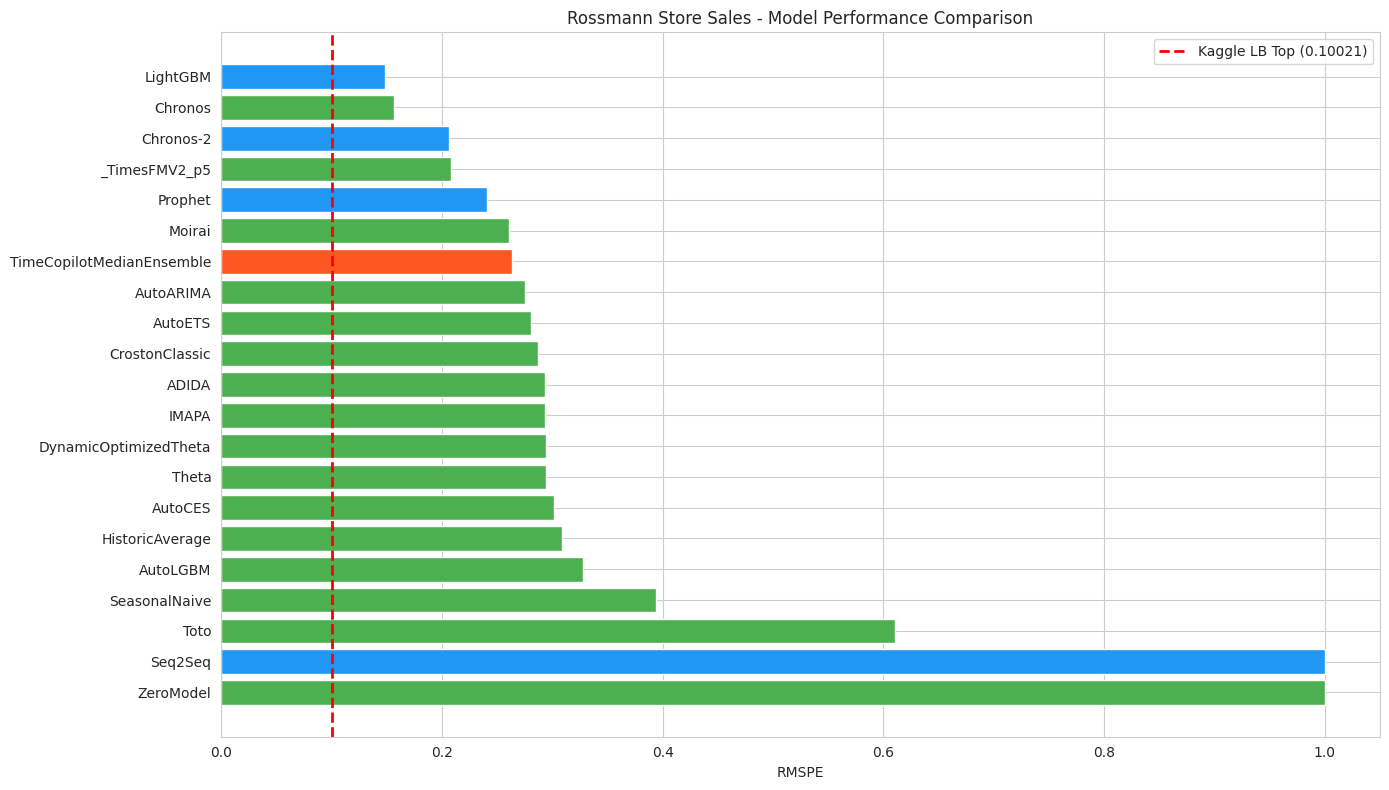

In [8]:
# メトリクス棒グラフ
fig, ax = plt.subplots(figsize=(14, 8))

# 色分け
colors = []
for model in summary_table["model"]:
    if model in BASELINE_MODELS:
        colors.append("#2196F3")  # Blue for baseline
    elif model == "TimeCopilotMedianEnsemble":
        colors.append("#FF5722")  # Orange for ensemble
    elif model in timecopilot_individual_models:
        colors.append("#4CAF50")  # Green for TimeCopilot models
    else:
        colors.append("#9E9E9E")  # Gray for others

bars = ax.barh(summary_table["model"], summary_table["metric"], color=colors)
ax.axvline(x=KAGGLE_LB_TOP, color="red", linestyle="--", linewidth=2, label=f"Kaggle LB Top ({KAGGLE_LB_TOP})")
ax.set_xlabel(f"{METRIC_NAME.upper()}")
ax.set_title("Rossmann Store Sales - Model Performance Comparison")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 時系列予測グラフ - TimeCopilotモデル全比較

In [9]:
def plot_forecast_comparison(
    unique_id: str,
    context_df: pd.DataFrame,
    actuals_df: pd.DataFrame,
    predictions: dict[str, pd.DataFrame],
    models_to_plot: list[str],
    metrics_df: pd.DataFrame,
    metric_name: str,
    title: str,
    save_path: Path | None = None,
) -> None:
    """予測結果を時系列グラフで比較"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # データ取得
    ctx = context_df[context_df["unique_id"] == unique_id].sort_values("ds")
    act = actuals_df[actuals_df["unique_id"] == unique_id].sort_values("ds")
    
    # カラーパレット
    colors = plt.cm.tab20(np.linspace(0, 1, len(models_to_plot)))
    
    # === Plot 1: 全体像（コンテキスト + 予測期間） ===
    ax1 = axes[0, 0]
    ax1.plot(ctx["ds"], ctx["y"], color="lightblue", linewidth=1, label="Context")
    ax1.plot(act["ds"], act["y"], color="green", linewidth=2, marker="o", markersize=3, label="Ground Truth")
    
    for i, model_name in enumerate(models_to_plot[:5]):  # 上位5モデルのみ
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                metric_val = metrics_df[metrics_df["model"] == model_name]["metric"].values
                metric_str = f" ({metric_name.upper()}={metric_val[0]:.4f})" if len(metric_val) > 0 else ""
                ax1.plot(
                    pred_series["ds"], pred_series["yhat"],
                    linestyle="--", color=colors[i], linewidth=1.5,
                    label=f"{model_name}{metric_str}"
                )
    
    ax1.axvline(x=act["ds"].min(), color="gray", linestyle=":", alpha=0.7)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Sales")
    ax1.set_title(f"Full View: Context + Forecast ({unique_id})")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.tick_params(axis="x", rotation=45)
    
    # === Plot 2: 予測期間のズーム ===
    ax2 = axes[0, 1]
    ax2.plot(act["ds"], act["y"], color="green", linewidth=2, marker="o", markersize=4, label="Ground Truth")
    
    for i, model_name in enumerate(models_to_plot):
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                metric_val = metrics_df[metrics_df["model"] == model_name]["metric"].values
                metric_str = f" ({metric_val[0]:.4f})" if len(metric_val) > 0 else ""
                ax2.plot(
                    pred_series["ds"], pred_series["yhat"],
                    linestyle="--", marker=".", color=colors[i], linewidth=1.5,
                    label=f"{model_name}{metric_str}"
                )
    
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Sales")
    ax2.set_title(f"Forecast Zoom ({unique_id})")
    ax2.legend(loc="upper right", fontsize=7, ncol=2)
    ax2.tick_params(axis="x", rotation=45)
    
    # === Plot 3: 予測誤差 ===
    ax3 = axes[1, 0]
    
    for i, model_name in enumerate(models_to_plot[:8]):  # 上位8モデル
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                merged = act.merge(pred_series, on=["unique_id", "ds"], how="inner")
                if not merged.empty:
                    # y > 0 のみで誤差計算（RMSPE用）
                    merged_valid = merged[merged["y"] > 0]
                    if not merged_valid.empty:
                        error = np.abs(merged_valid["yhat"] - merged_valid["y"]) / merged_valid["y"]
                        ax3.plot(
                            range(len(error)), error,
                            color=colors[i], linewidth=1.5, label=model_name
                        )
    
    ax3.set_xlabel("Prediction Step")
    ax3.set_ylabel("Percentage Error")
    ax3.set_title(f"Prediction Error ({unique_id})")
    ax3.legend(loc="upper right", fontsize=8)
    
    # === Plot 4: メトリクス比較バー ===
    ax4 = axes[1, 1]
    
    plot_metrics = metrics_df[metrics_df["model"].isin(models_to_plot)].copy()
    plot_metrics = plot_metrics.sort_values("metric")
    
    bar_colors = ["#4CAF50" if m in timecopilot_individual_models else "#2196F3" for m in plot_metrics["model"]]
    ax4.barh(plot_metrics["model"], plot_metrics["metric"], color=bar_colors)
    ax4.set_xlabel(f"{metric_name.upper()}")
    ax4.set_title(f"Model Performance - {metric_name.upper()}")
    ax4.invert_yaxis()
    
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    
    plt.show()

In [10]:
# ランダムに店舗を選択（売上が多い店舗を優先）
store_sales = actuals_df.groupby("unique_id")["y"].sum().sort_values(ascending=False)
np.random.seed(42)
# 売上上位50店舗からランダム選択
top_stores = store_sales.head(50).index.tolist()
sample_series = np.random.choice(top_stores, size=3, replace=False)

print(f"Sample stores for visualization: {sample_series}")

Sample stores for visualization: ['store_335' 'store_453' 'store_192']


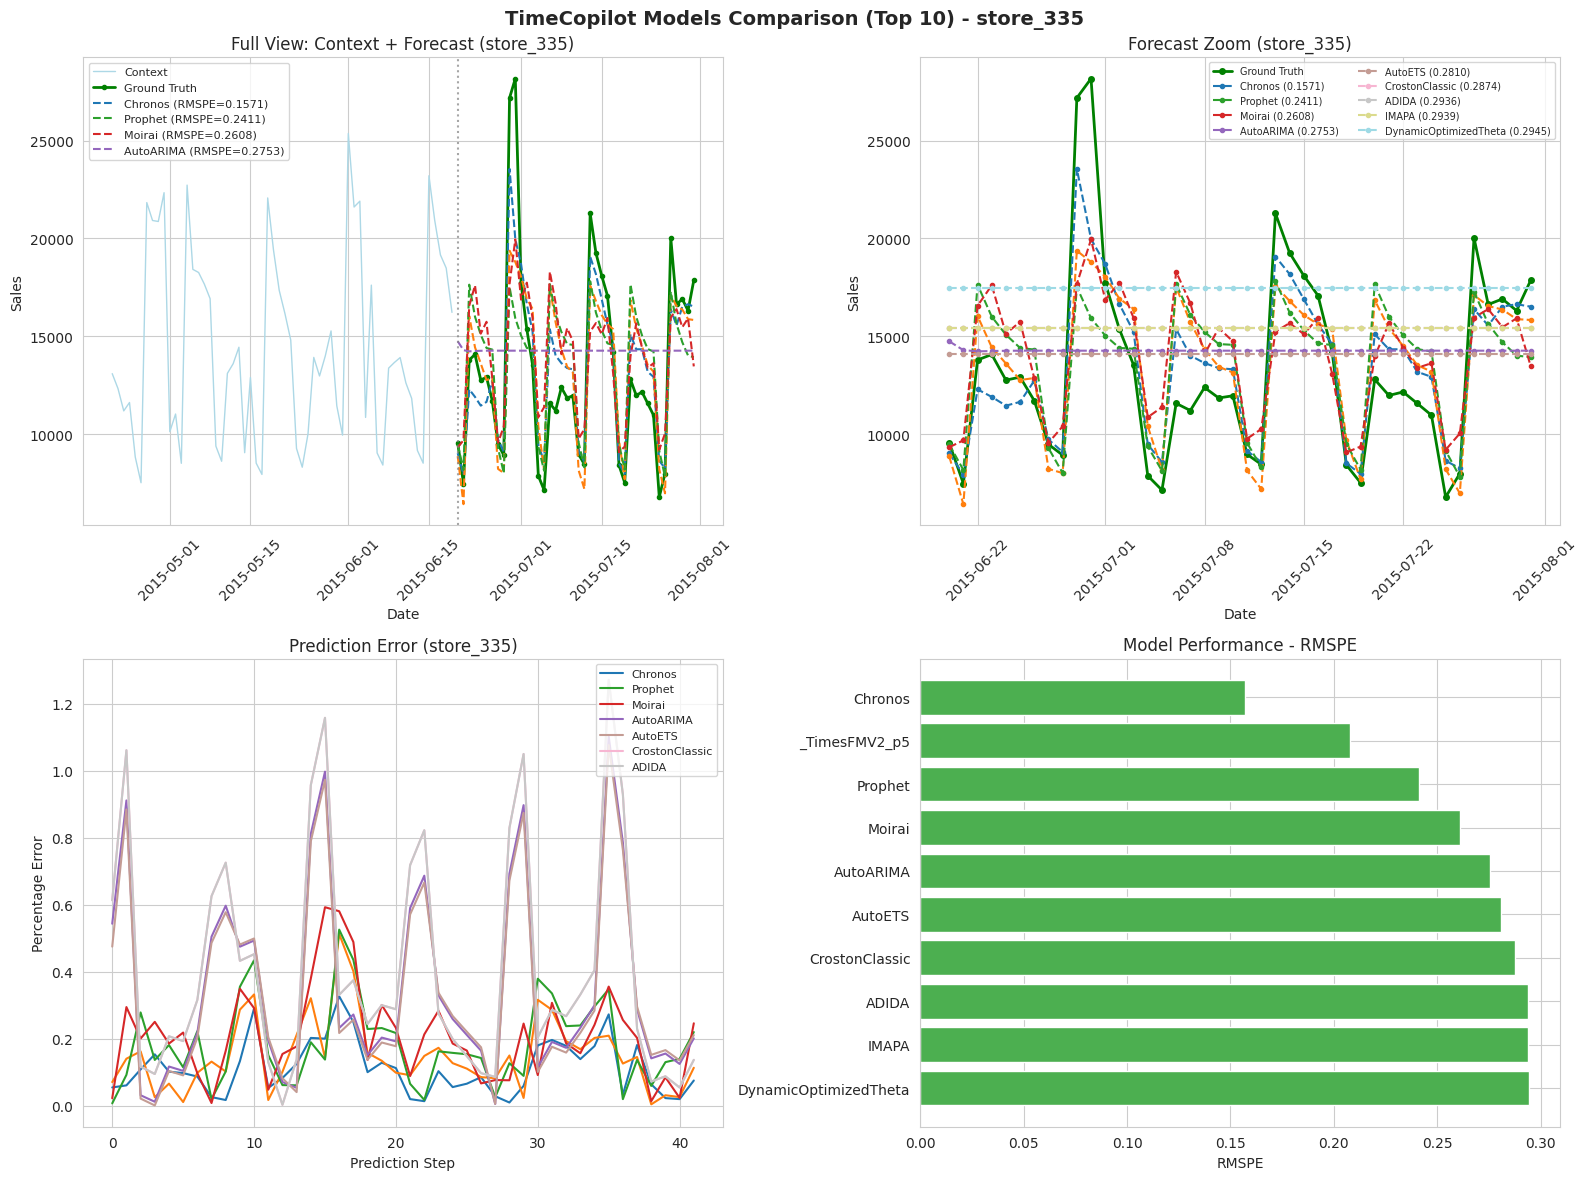

In [11]:
# TimeCopilotモデル全比較（1つの店舗）
# 上位モデルのみプロット
tc_metrics = metrics_df[metrics_df["model"].isin(timecopilot_individual_models)].sort_values("metric")
top_tc_models = tc_metrics["model"].tolist()[:10]  # 上位10モデル

for series_id in sample_series[:1]:
    plot_forecast_comparison(
        unique_id=series_id,
        context_df=context_df,
        actuals_df=actuals_df,
        predictions=predictions,
        models_to_plot=top_tc_models,
        metrics_df=metrics_df,
        metric_name=METRIC_NAME,
        title=f"TimeCopilot Models Comparison (Top 10) - {series_id}",
        save_path=EXPERIMENT_DIR / f"timecopilot_models_comparison_{series_id.replace('_', '-')}.png",
    )

## 6. 時系列予測グラフ - TimeCopilotベスト vs ベースライン4種

In [12]:
# TimeCopilot内のベストモデルを特定
tc_metrics = metrics_df[metrics_df["model"].isin(timecopilot_individual_models)]
best_tc_model = tc_metrics.loc[tc_metrics["metric"].idxmin(), "model"]

print(f"Best TimeCopilot model: {best_tc_model}")
print(f"Best TimeCopilot {METRIC_NAME.upper()}: {tc_metrics['metric'].min():.5f}")

# 比較対象モデル
comparison_models = BASELINE_MODELS + [best_tc_model, "TimeCopilotMedianEnsemble"]
print(f"\nComparison models: {comparison_models}")

Best TimeCopilot model: Chronos
Best TimeCopilot RMSPE: 0.15707

Comparison models: ['LightGBM', 'Prophet', 'Seq2Seq', 'Chronos-2', 'Chronos', 'TimeCopilotMedianEnsemble']


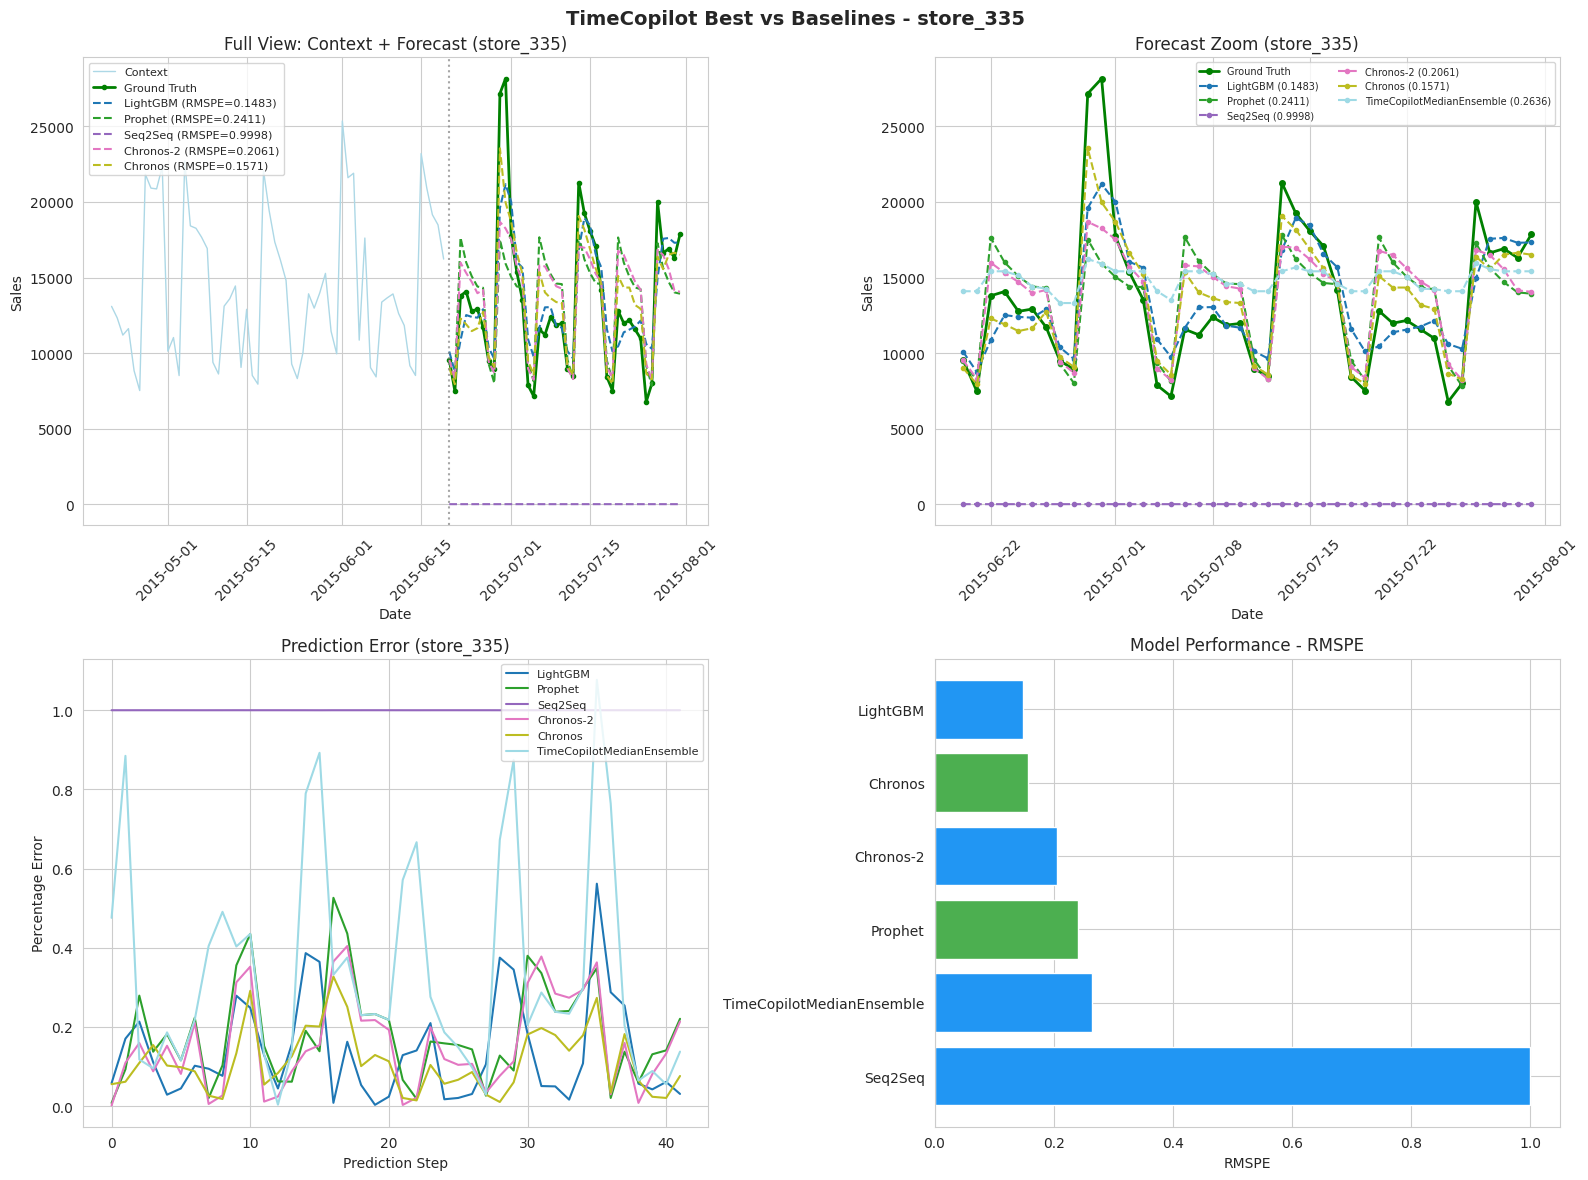

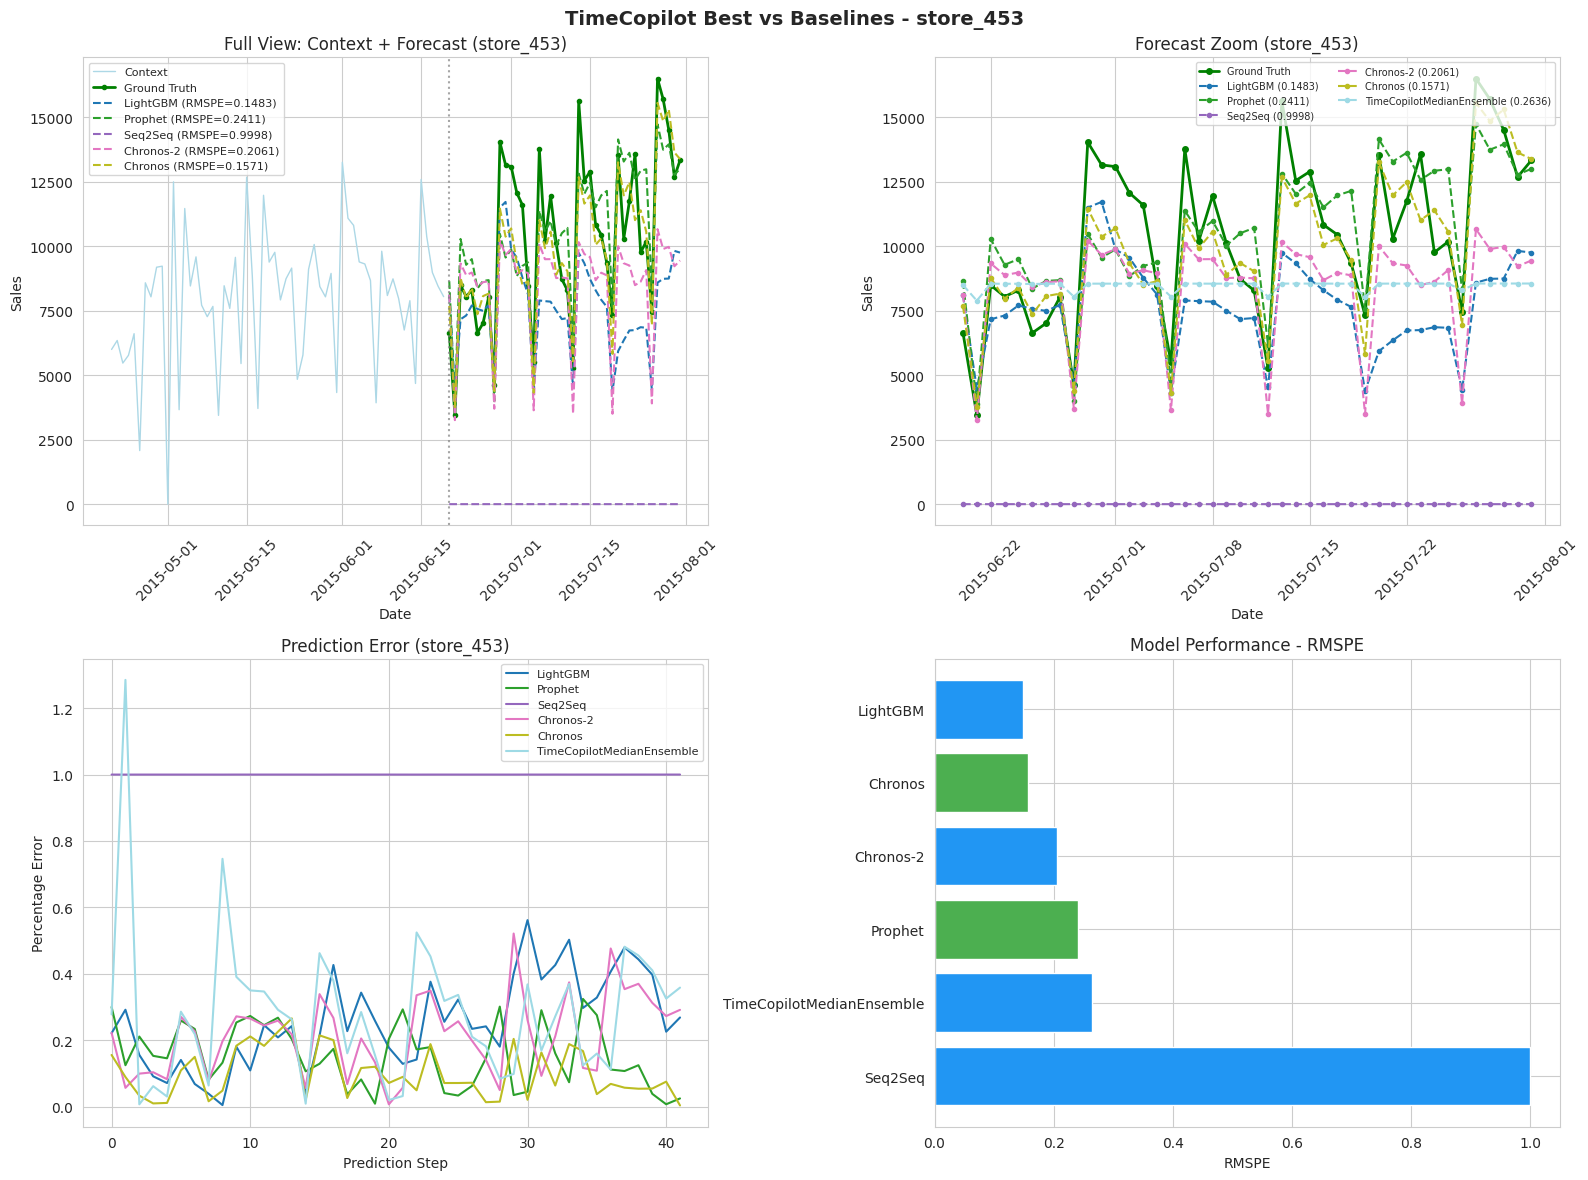

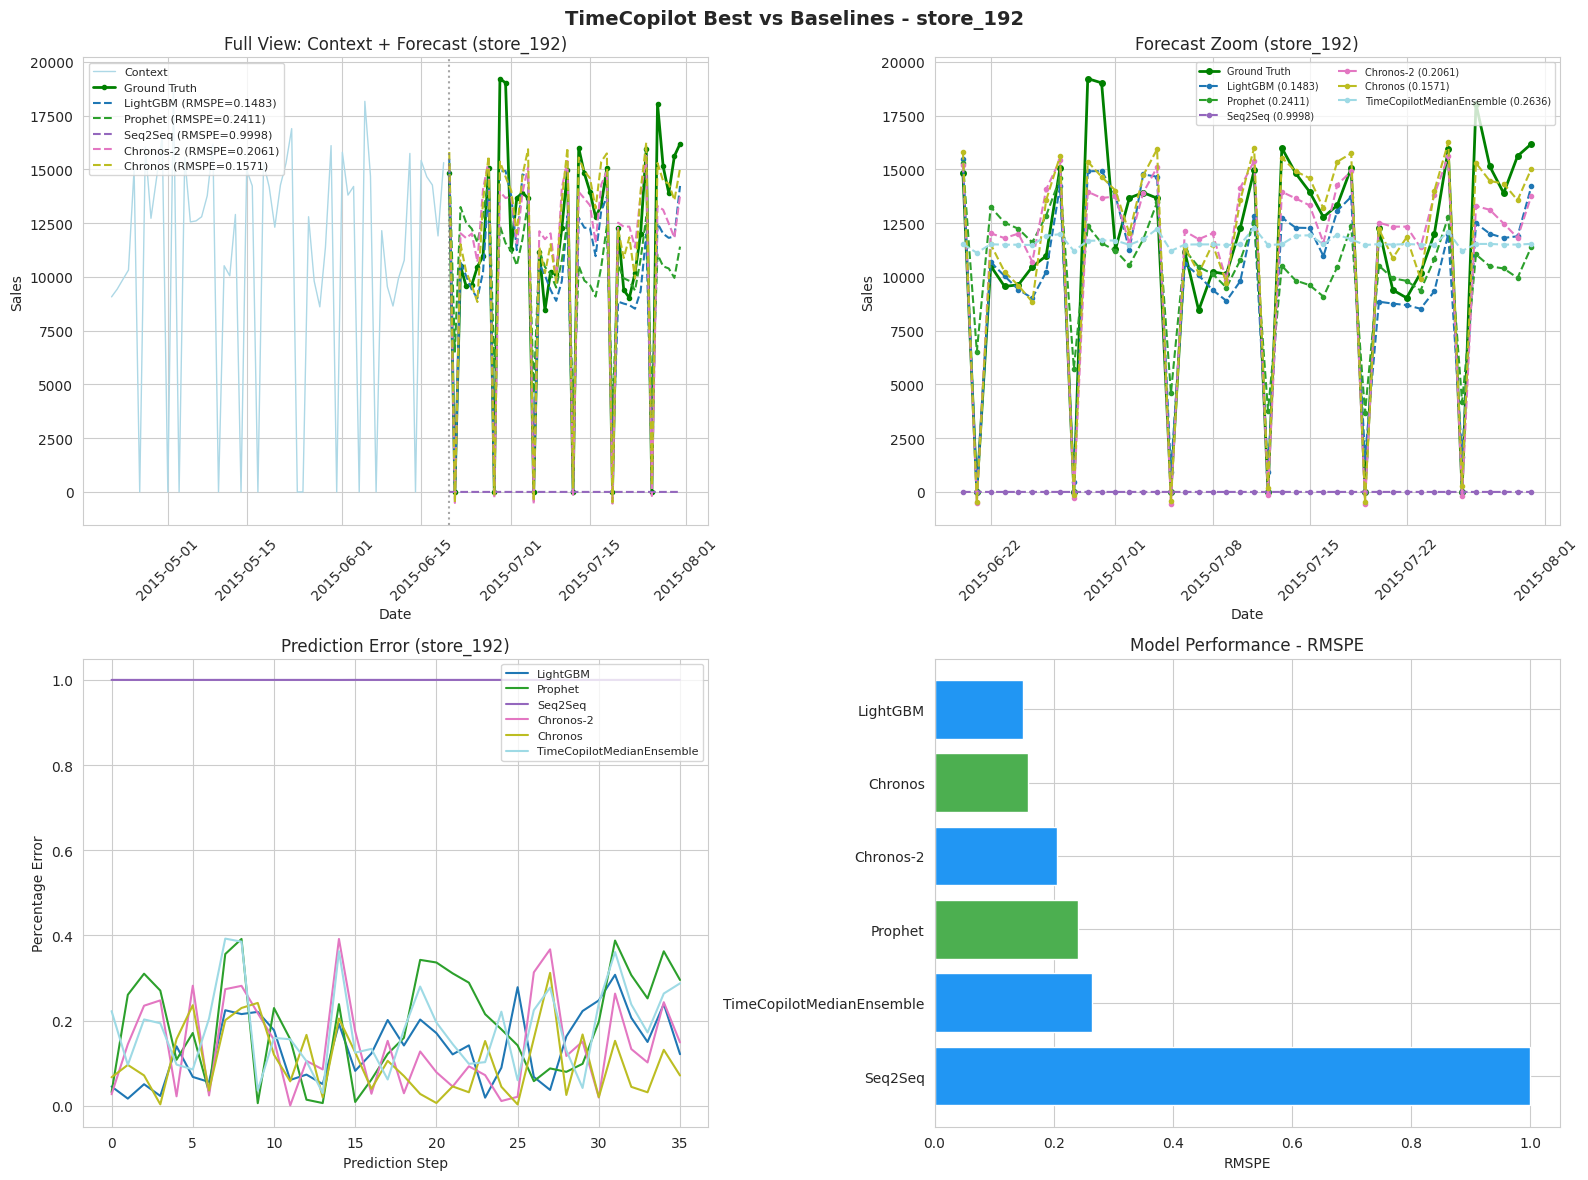

In [13]:
# ベースラインとTimeCopilotベストの比較
for series_id in sample_series:
    plot_forecast_comparison(
        unique_id=series_id,
        context_df=context_df,
        actuals_df=actuals_df,
        predictions=predictions,
        models_to_plot=comparison_models,
        metrics_df=metrics_df,
        metric_name=METRIC_NAME,
        title=f"TimeCopilot Best vs Baselines - {series_id}",
        save_path=EXPERIMENT_DIR / f"baseline_comparison_{series_id.replace('_', '-')}.png",
    )

## 7. 店舗ごとの誤差分布

In [14]:
def compute_series_metrics_rmspe(
    actuals_df: pd.DataFrame,
    predictions: dict[str, pd.DataFrame],
    models: list[str],
) -> pd.DataFrame:
    """店舗ごとのRMSPEを計算"""
    results = []
    
    for model_name in models:
        if model_name not in predictions:
            continue
        pred = predictions[model_name]
        merged = actuals_df.merge(pred, on=["unique_id", "ds"], how="inner")
        
        for uid, group in merged.groupby("unique_id"):
            # y > 0 のみで計算
            valid = group[group["y"] > 0]
            if valid.empty:
                continue
            
            y_true = valid["y"].values
            y_pred = valid["yhat"].values
            
            # RMSPE計算
            pct_error = (y_true - y_pred) / y_true
            rmspe = np.sqrt(np.mean(pct_error ** 2))
            
            results.append({
                "model": model_name,
                "unique_id": uid,
                "rmspe": rmspe,
            })
    
    return pd.DataFrame(results)

# 店舗ごとのメトリクス計算
series_metrics = compute_series_metrics_rmspe(
    actuals_df=actuals_df,
    predictions=predictions,
    models=comparison_models,
)

print(f"Series metrics shape: {series_metrics.shape}")
series_metrics.head()

Series metrics shape: (6690, 3)


,model,unique_id,rmspe
0,LightGBM,store_1,0.104915
1,LightGBM,store_10,0.140083
2,LightGBM,store_100,0.126006
3,LightGBM,store_1000,0.175342
4,LightGBM,store_1001,0.098413


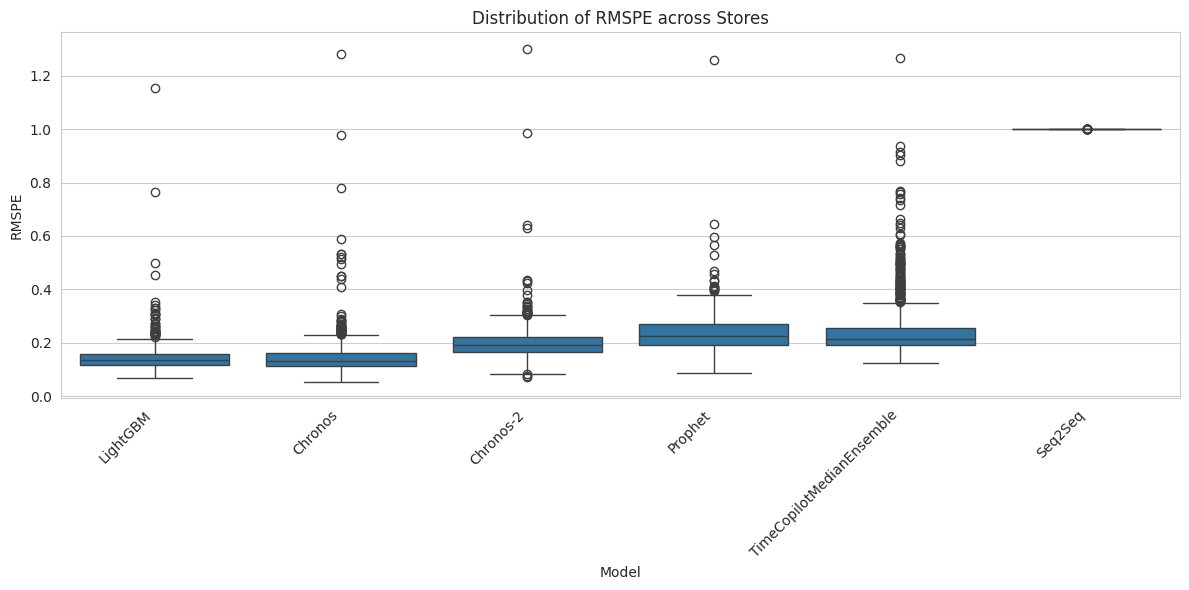

In [15]:
# 箱ひげ図
fig, ax = plt.subplots(figsize=(12, 6))

# モデル順序を指定（メトリクス順）
model_order = metrics_df[metrics_df["model"].isin(comparison_models)].sort_values("metric")["model"].tolist()

sns.boxplot(
    data=series_metrics,
    x="model",
    y="rmspe",
    order=model_order,
    ax=ax,
)

ax.set_xlabel("Model")
ax.set_ylabel(f"{METRIC_NAME.upper()}")
ax.set_title("Distribution of RMSPE across Stores")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / "store_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. サマリレポート

In [16]:
# サマリレポート生成
print("="*70)
print("Rossmann Store Sales - Experiment Summary")
print("="*70)
print(f"\nDataset: Rossmann Store Sales")
print(f"Metric: {METRIC_NAME.upper()} (excluding Sales=0)")
print(f"Horizon: {HORIZON} days")
print(f"Number of stores: {actuals_df['unique_id'].nunique()}")
print(f"\nKaggle LB Top Score (reference): {KAGGLE_LB_TOP}")

print("\n" + "-"*70)
print("Top 5 Models:")
print("-"*70)
for i, row in metrics_df.head(5).iterrows():
    model_type = "(TimeCopilot)" if row["model"] in timecopilot_individual_models else "(Baseline)" if row["model"] in BASELINE_MODELS else ""
    print(f"  {i+1}. {row['model']:30s} {METRIC_NAME.upper()}: {row['metric']:.5f}  {model_type}")

print("\n" + "-"*70)
print("Baseline Models Performance:")
print("-"*70)
baseline_metrics = metrics_df[metrics_df["model"].isin(BASELINE_MODELS)].sort_values("metric")
for i, row in baseline_metrics.iterrows():
    print(f"  {row['model']:20s} {METRIC_NAME.upper()}: {row['metric']:.5f}")

print("\n" + "-"*70)
print("TimeCopilot Performance:")
print("-"*70)
print(f"  Best Model: {best_tc_model}")
print(f"  Best {METRIC_NAME.upper()}: {tc_metrics['metric'].min():.5f}")
ensemble_metric = metrics_df[metrics_df["model"] == "TimeCopilotMedianEnsemble"]["metric"].values
if len(ensemble_metric) > 0:
    print(f"  MedianEnsemble {METRIC_NAME.upper()}: {ensemble_metric[0]:.5f}")

print("\n" + "="*70)

Rossmann Store Sales - Experiment Summary

Dataset: Rossmann Store Sales
Metric: RMSPE (excluding Sales=0)
Horizon: 42 days
Number of stores: 1115

Kaggle LB Top Score (reference): 0.10021

----------------------------------------------------------------------
Top 5 Models:
----------------------------------------------------------------------
  1. LightGBM                       RMSPE: 0.14825  (Baseline)
  2. Chronos                        RMSPE: 0.15707  (TimeCopilot)
  3. Chronos-2                      RMSPE: 0.20614  (Baseline)
  4. _TimesFMV2_p5                  RMSPE: 0.20798  (TimeCopilot)
  5. Prophet                        RMSPE: 0.24105  (TimeCopilot)

----------------------------------------------------------------------
Baseline Models Performance:
----------------------------------------------------------------------
  LightGBM             RMSPE: 0.14825
  Chronos-2            RMSPE: 0.20614
  Prophet              RMSPE: 0.24105
  Seq2Seq              RMSPE: 0.99984

-----